In [390]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.datasets import make_blobs
from helper_function import plot_decision_boundary

In [391]:
def accuracy_fn(y_true: torch.Tensor, y_pred: torch.Tensor) -> float:
    """Calculates accuracy for multi-class classification."""
    correct = (y_true == y_pred).sum().item()
    total = len(y_true)
    return (correct / total) * 100  # returns accuracy in %

In [392]:
X, y = make_blobs(n_samples = 1000, cluster_std = 1.5, centers = 4, n_features = 2, random_state = 42)
X.shape

(1000, 2)

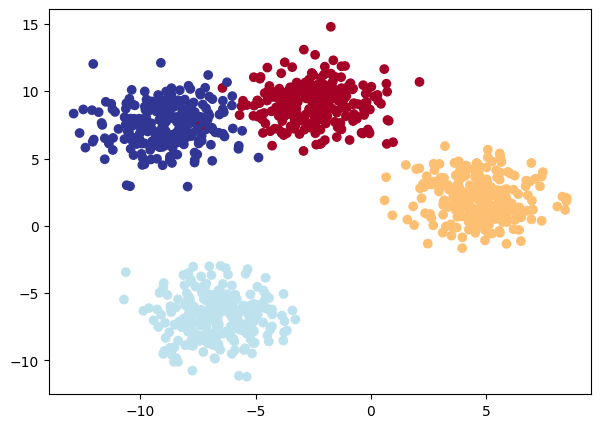

In [393]:
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap = plt.cm.RdYlBu)

In [394]:
X, y = torch.from_numpy(X).type(torch.float), torch.from_numpy(y).type(torch.float)

In [395]:
device = "mps" if torch.mps.is_available() else "cpu"
device

'mps'

In [396]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
len(X_train)

800

In [397]:
X_train.shape, y_train.shape

(torch.Size([800, 2]), torch.Size([800]))

In [398]:
class BlobsClassification(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer_1 = nn.Linear(in_features = 2, out_features = 32)
        self.layer_2 = nn.Linear(in_features = 32, out_features = 32)
        self.layer_3 = nn.Linear(in_features = 32, out_features = 4)
        self.relu = nn.ReLU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

In [383]:
model = BlobsClassification().to(device)
model

BlobsClassification(
  (layer_1): Linear(in_features=2, out_features=32, bias=True)
  (layer_2): Linear(in_features=32, out_features=32, bias=True)
  (layer_3): Linear(in_features=32, out_features=4, bias=True)
  (relu): ReLU()
)

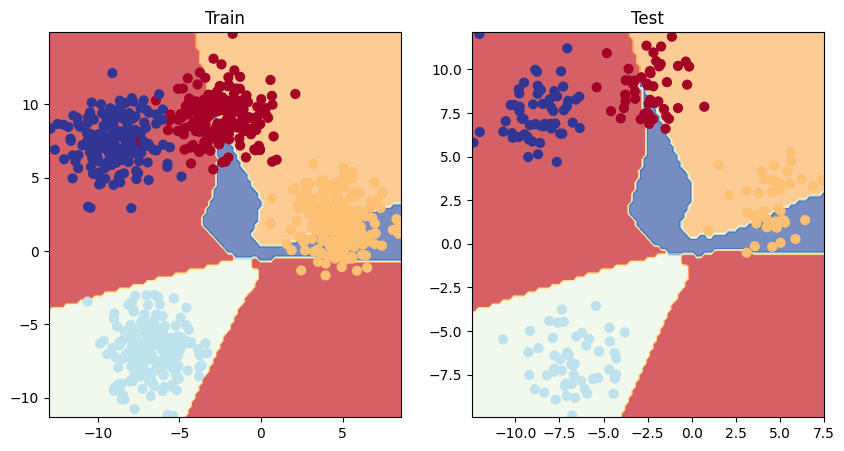

In [159]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)

In [384]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model.parameters(), lr = 0.01)

In [385]:
X_train, X_test = X_train.to(device), X_test.to(device)
y_train, y_test = y_train.to(device), y_test.to(device)

In [386]:
epochs = 200
total_epochs = []
losses = []
test_losses = []

for epoch in range(epochs):
    model.train()

    y_logits = model(X_train)
    y_pred = torch.argmax(y_logits, dim = 1)
    train_accuracy = accuracy_fn(y_train.detach().cpu(), y_pred.detach().cpu())

    loss = loss_fn(y_logits, y_train)
    optimizer.zero_grad()

    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    model.eval()
    with torch.inference_mode():
        y_test_logits = model(X_test)
        y_test_pred = torch.argmax(y_test_logits, dim = 1)
        test_accuracy = accuracy_fn(y_test.detach().cpu(), y_test_pred.detach().cpu())

        test_loss = loss_fn(y_test_logits, y_test)
        test_losses.append(test_loss.item())

    total_epochs.append(epoch)
    if epoch % (0.1 * epochs) == 0:
        print(f"Train Loss: {loss} | Test Loss: {test_loss}")
        print(f"Train Accuracy: {train_accuracy} | Test Accuracy: {test_accuracy}\n")

Train Loss: 1.638911485671997 | Test Loss: 1.0905673503875732
Train Accuracy: 24.625 | Test Accuracy: 63.0

Train Loss: 0.027175161987543106 | Test Loss: 0.017530089244246483
Train Accuracy: 99.25 | Test Accuracy: 99.5

Train Loss: 0.023117557168006897 | Test Loss: 0.010364915244281292
Train Accuracy: 99.125 | Test Accuracy: 99.5

Train Loss: 0.021426472812891006 | Test Loss: 0.010599685832858086
Train Accuracy: 99.375 | Test Accuracy: 99.5

Train Loss: 0.020436685532331467 | Test Loss: 0.00917959213256836
Train Accuracy: 99.5 | Test Accuracy: 99.5

Train Loss: 0.019558897241950035 | Test Loss: 0.008620822802186012
Train Accuracy: 99.5 | Test Accuracy: 99.5

Train Loss: 0.018717434257268906 | Test Loss: 0.007770221214741468
Train Accuracy: 99.5 | Test Accuracy: 100.0

Train Loss: 0.017879635095596313 | Test Loss: 0.0067886547185480595
Train Accuracy: 99.5 | Test Accuracy: 100.0

Train Loss: 0.017133330926299095 | Test Loss: 0.006089774426072836
Train Accuracy: 99.5 | Test Accuracy: 100

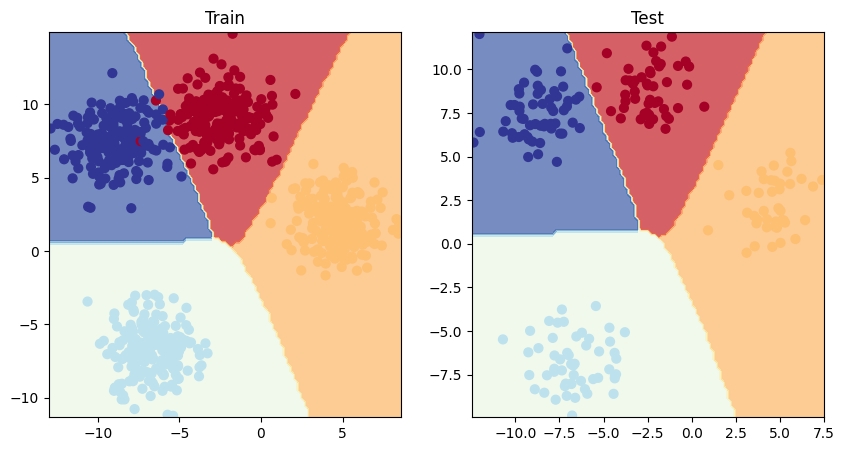

In [387]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)

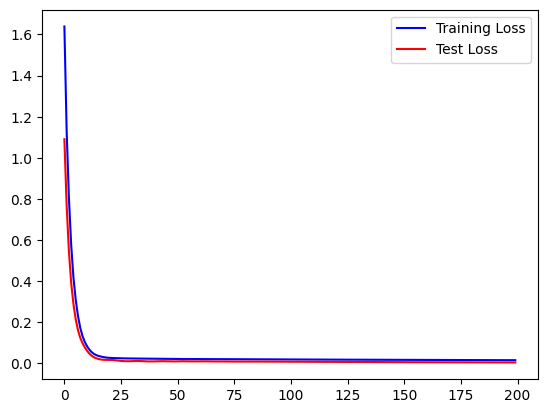

In [388]:
plt.plot(total_epochs, losses, label = "Training Loss", c = "blue")
plt.plot(total_epochs, test_losses, label = "Test Loss", c = "red")
plt.legend()
plt.show()

In [389]:
model.eval()
with torch.inference_mode():
    y_logits = model(X_test)
    y_pred = torch.argmax(y_logits, dim = 1)

y_pred[:10], y_test[:10]

RuntimeError: Tensor for argument weight is on cpu but expected on mps